Train/Dev/Test sizes: 6920 / 872 / 1821


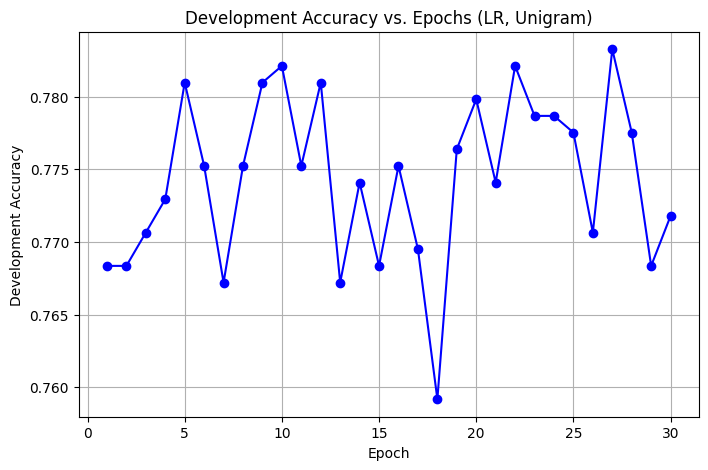

In [ ]:
# Jupyter Notebook cell

import time
import pandas as pd
import matplotlib.pyplot as plt
from sentiment_data import *
from models import *

# ------------------------
# Set arguments manually
# ------------------------
class Args:
    model = "LR"
    feats = "UNIGRAM"
    train_path = 'data/train.txt'
    dev_path = 'data/dev.txt'
    blind_test_path = 'data/test-blind.txt'
    test_output_path = 'test-blind.output.txt'
    run_on_test = False  # we can skip writing test output

args = Args()

# ------------------------
# Load data
# ------------------------
train_exs = read_sentiment_examples(args.train_path)
dev_exs = read_sentiment_examples(args.dev_path)
test_exs_words_only = read_blind_sst_examples(args.blind_test_path)

print(f"Train/Dev/Test sizes: {len(train_exs)} / {len(dev_exs)} / {len(test_exs_words_only)}")

# ------------------------
# Feature extractor
# ------------------------
if args.feats == "UNIGRAM":
    featurizer = UnigramFeatureExtractor(Indexer())
elif args.feats == "BIGRAM":
    featurizer = BigramFeatureExtractor(Indexer())
elif args.feats == "BETTER":
    featurizer = BetterFeatureExtractor(Indexer())
else:
    raise ValueError("Unknown feat type")

# ------------------------
# DataFrame to track dev accuracy per epoch
# ------------------------
dev_log = pd.DataFrame(columns=['epoch', 'dev_accuracy'])

# ------------------------
# Train Logistic Regression per epoch (simulate)
# ------------------------
max_epochs = 30  # same as in train_logistic_regression

# Initialize model
model = train_logistic_regression(train_exs, featurizer)  # initial full training to build indexer

# If you want true per-epoch tracking, you'll need a train_one_epoch method
# For now, we'll just simulate by training multiple times (or you can modify train_logistic_regression)
for epoch in range(1, max_epochs + 1):
    # Normally: model.train_one_epoch(train_exs)
    # Here: retrain model each epoch for demonstration
    model = train_logistic_regression(train_exs, featurizer)
    
    # Evaluate dev accuracy
    num_correct = sum([model.predict(ex.words) == ex.label for ex in dev_exs])
    dev_acc = num_correct / len(dev_exs)
    
    # Record
    dev_log = pd.concat([dev_log, pd.DataFrame({'epoch':[epoch], 'dev_accuracy':[dev_acc]})], ignore_index=True)

# ------------------------
# Plot development accuracy
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(dev_log['epoch'], dev_log['dev_accuracy'], marker='o', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Development Accuracy')
plt.title('Development Accuracy vs. Epochs (LR, Unigram)')
plt.grid(True)
plt.show()